## Imports

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.spatial.distance import cdist
from scipy.stats import wilcoxon

from analysis_helpers import Episode, Participant
from analysis_helpers.constants import FIG_DIR
from analysis_helpers.functions import mean_center, rankbiserialr

## Functions

In [2]:
def segment_recall(
    rec_ep_similarity, 
    fwd_transition_penalty=1.5, 
    other_transition_penalty=3.0
):
    n_recall_tpts, n_episode_events = rec_ep_similarity.shape

    # emission fit (z-score so transition penalties are equivalent across recalls)
    emission_scores = (
        (rec_ep_similarity - rec_ep_similarity.mean()) 
        / (rec_ep_similarity.std() + 1e-8)
    )
    
    # log transition cost matrix
    ep_events_ixs = np.arange(n_episode_events)
    lags = ep_events_ixs[None, :] - ep_events_ixs[:, None]
    log_transition_costs = np.full((n_episode_events, n_episode_events), 
                                   -other_transition_penalty, 
                                   dtype=float)
    log_transition_costs[lags == 1] = -fwd_transition_penalty
    np.fill_diagonal(log_transition_costs, 0)

    # Viterbi forward pass: best score of any label-path ending in each event
    delta = emission_scores[0].copy()
    backpointers = np.zeros((n_recall_tpts, n_episode_events), int)
    for rec_tpt in range(1, n_recall_tpts):
        scores = delta[:, None] + log_transition_costs
        backpointers[rec_tpt] = scores.argmax(axis=0)
        delta = scores.max(axis=0) + emission_scores[rec_tpt]

    # backtrack to recover best label sequence
    state_labels = np.empty(n_recall_tpts, int)
    state_labels[-1] = delta.argmax()
    for rect_tpt in range(n_recall_tpts - 2, -1, -1):
        state_labels[rect_tpt] = backpointers[rect_tpt + 1, state_labels[rect_tpt + 1]]

    # collapse consecutive identical labels into events
    changes = np.flatnonzero(np.diff(state_labels) != 0) + 1
    starts = np.concatenate(([0], changes))
    stops = np.concatenate((changes - 1, [n_recall_tpts - 1]))
    event_bounds = np.column_stack((starts, stops))
    event_matches = np.array([state_labels[s] for s in starts])
    
    return event_bounds, event_matches

In [3]:
def create_event_trajectory(trajectory, event_onsets):
    """
    Note: event_onsets is a 1D array of indicies of the first timepoint 
    for each event (optionally including/excluding the first, i.e., tpt 0)
    """
    event_onsets = np.asarray(event_onsets, dtype=int)
    if event_onsets[0] == 0:
        event_onsets = event_onsets[1:]
    
    chunks = np.split(trajectory, event_onsets)
    return np.vstack([chunk.mean(axis=0) for chunk in chunks])

## Load data

In [4]:
atlep1 = Episode('atlep1')

participants = Participant.load_all()
avg_participant = Participant('average')

N_EVENTS_RANGE = np.arange(2, 51)
N_BOOTS_CI = 10_000

## Load episode $K$-optimization results from HPC cluster, segment trajectory and save
see [code/cluster-scripts/eventseg/](https://github.com/ContextLab/memory-dynamics/tree/master/code/cluster-scripts/eventseg)

In [5]:
episode_event_labels = atlep1.eventseg_model.segments_[0].argmax(axis=1)
bounds_aug = np.flatnonzero(np.diff(episode_event_labels, prepend=-1, append=-1))
episode_event_bounds = np.column_stack((bounds_aug[:-1], bounds_aug[1:] - 1))

atlep1.events = create_event_trajectory(atlep1.trajectory, 
                                        episode_event_bounds[:, 0])
# np.save(atlep1.data_dir.joinpath('events.npy'), atlep1.events)

## Plot episode $K$-optimization curve & event boundaries

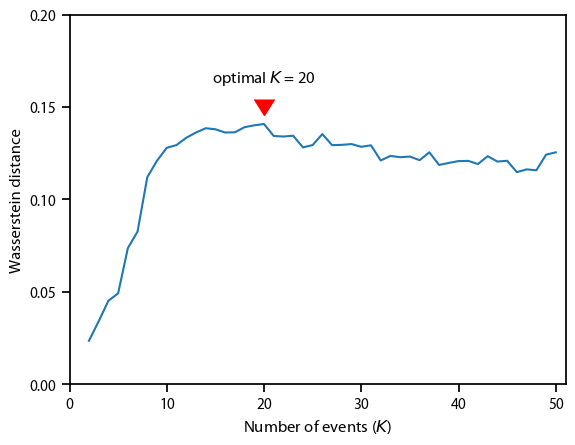

In [6]:
with sns.plotting_context('notebook'):
    episode_best_k = N_EVENTS_RANGE[atlep1.eventseg_kvals.argmax()]
    ax = sns.lineplot(x=N_EVENTS_RANGE, y=atlep1.eventseg_kvals)
    ax.plot(episode_best_k, 
            atlep1.eventseg_kvals.max() + 0.005, 
            c='r', 
            marker=7, 
            markersize=15)
    ax.text(episode_best_k, 
            atlep1.eventseg_kvals.max() + 0.02, 
            f'optimal $K$ = {episode_best_k}', va='bottom', ha='center')
    ax.set_xlim(0, N_EVENTS_RANGE[-1] + 1)
    ax.set_ylim(0, 0.2)
    ax.set_yticks(np.linspace(0, 0.2, 5))
    ax.set_xlabel('Number of events ($K$)')
    ax.set_ylabel('Wasserstein distance')
#     plt.savefig(FIG_DIR / 'k-optimization-episode.pdf', bbox_inches='tight')
    plt.show()

## Segment recall trajectories by episode-similarity time series

In [7]:
episode_events_centered = mean_center(atlep1.events)

for rectype in ('atlep1', 'delayed'):
    for p in participants:
        recall_trajectory = p.trajectories[rectype]
        recall_trajectory_centered = mean_center(recall_trajectory)
        similarity_timeseries = 1 - cdist(recall_trajectory_centered, 
                                          episode_events_centered, 
                                          'cosine')
        event_bounds, event_matches = segment_recall(similarity_timeseries)
        recall_events = create_event_trajectory(recall_trajectory, event_bounds[:, 0])
        
        p.event_bounds[rectype] = event_bounds
        p.event_matches[rectype] = event_matches
        p.events[rectype] = recall_events
        
#         np.save(p.data_dir / f'{rectype}_recall_event_bounds.npy', event_bounds)
#         np.save(p.data_dir / f'{rectype}_recall_event_matches.npy', event_matches)
#         np.save(p.data_dir / f'{rectype}_recall_events.npy', recall_events)

In [8]:
# number of recall events
n_events_imm = np.array([len(p.events['atlep1']) for p in participants])
n_events_del = np.array([len(p.events['delayed']) for p in participants])

T, p = wilcoxon(n_events_imm, n_events_del, alternative='two-sided', method='exact')
rb = rankbiserialr(n_events_imm, n_events_del)

paired_diffs = n_events_imm - n_events_del
mean_diff = paired_diffs.mean()

diff_boot_means = []
rng = np.random.default_rng(0)
for boot in range(N_BOOTS_CI):
    boot_ixs = rng.integers(0, len(paired_diffs), len(paired_diffs))
    diff_boot_means.append(paired_diffs[boot_ixs].mean())

diff_mean_ci_low, diff_mean_ci_high = np.percentile(diff_boot_means, (2.5, 97.5))

T, p, rb = T.item(), p.item(), rb.item()
diff_mean_ci_low, diff_mean_ci_high = diff_mean_ci_low.item(), diff_mean_ci_high.item()
print(f'mean n immediate recall events: {n_events_imm.mean():.3f}')
print(f'mean n delayed recall events: {n_events_del.mean():.3f}')
print(f'mean paired difference: {paired_diffs.mean():.3f}, '
      f'95% CI = [{diff_mean_ci_low:.3f}, {diff_mean_ci_high:.3f}]')
print(f'{T=}, {p=:.4f}, {rb=:.4f}')

mean n immediate recall events: 18.245
mean n delayed recall events: 17.170
mean paired difference: 1.075, 95% CI = [0.358, 1.774]
T=321.5, p=0.0033, rb=0.4751


In [9]:
# number of episode events recalled
n_recalled_imm = np.array([len(np.unique(p.event_matches['atlep1'])) for p in participants])
n_recalled_del = np.array([len(np.unique(p.event_matches['delayed'])) for p in participants])

T, p = wilcoxon(n_recalled_imm, n_recalled_del, alternative='two-sided', method='exact')
rb = rankbiserialr(n_recalled_imm, n_recalled_del)

paired_diffs = n_recalled_imm - n_recalled_del
mean_diff = paired_diffs.mean()

diff_boot_means = []
rng = np.random.default_rng(0)
for boot in range(N_BOOTS_CI):
    boot_ixs = rng.integers(0, len(paired_diffs), len(paired_diffs))
    diff_boot_means.append(paired_diffs[boot_ixs].mean())

diff_mean_ci_low, diff_mean_ci_high = np.percentile(diff_boot_means, (2.5, 97.5))

T, p, rb = T.item(), p.item(), rb.item()
diff_mean_ci_low, diff_mean_ci_high = diff_mean_ci_low.item(), diff_mean_ci_high.item()
print(f'mean n events recalled (immediate): {n_recalled_imm.mean():.3f}')
print(f'mean n events recalled (delayed): {n_recalled_del.mean():.3f}')
print(f'mean paired difference: {paired_diffs.mean():.3f}, '
      f'95% CI = [{diff_mean_ci_low:.3f}, {diff_mean_ci_high:.3f}]')
print(f'{T=}, {p=:.4f}, {rb=:.4f}')

mean n events recalled (immediate): 16.981
mean n events recalled (delayed): 16.264
mean paired difference: 0.717, 95% CI = [0.226, 1.189]
T=199.0, p=0.0068, rb=0.4897


## Create average recall event sequence

In [10]:
for rectype in ('atlep1', 'delayed'):
    matched_rec_events = [[] for _ in atlep1.events]
    
    for episode_event_ix in range(atlep1.events.shape[0]):
        for p in participants:
            rec_events = p.events[rectype]
            event_matches = p.event_matches[rectype]
            matched_rec_event_ixs = np.flatnonzero(event_matches == episode_event_ix)
            if matched_rec_event_ixs.size == 0:
                continue
                
            avg_matched_rec = rec_events[matched_rec_event_ixs].mean(axis=0)
            matched_rec_events[episode_event_ix].append(avg_matched_rec)
            
    no_recs = [ix for ix, evs in enumerate(matched_rec_events) if len(evs) == 0]
    if any(no_recs):
        raise RuntimeError(f'Some episode events never recalled: {no_recs}')
        
    avg_participant.events[rectype] = np.array([np.mean(ev, axis=0) 
                                                for ev in matched_rec_events])
#     np.save(avg_participant.data_dir / f'{rectype}_recall_events.npy', 
#             avg_participant.events[rectype])
#     np.save(avg_participant.data_dir / f'{rectype}_recall_event_matches.npy', 
#             np.arange(atlep1.events.shape[0]))